In [1]:
import joblib
# Handle imports

import numpy as np

from CategoricalRandomForest import CategoricalRandomForest
import utils
from MfccFixedRandomForest import MfccFixedRandomForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from imblearn.over_sampling import SMOTE

from WeightedRandomForest import WeightedRandomForest


In [2]:
# Load metadata and features.

tracks = utils.load('../data/fma_metadata/tracks.csv')
genres = utils.load('../data/fma_metadata/genres.csv')
features = utils.load('../data/fma_metadata/features.csv')
echonest = utils.load('../data/fma_metadata/echonest.csv')


In [3]:
# Create genre mapping

def get_top_level_name(genre_id):
    row = genres.loc[genre_id]
    if row['parent'] == 0:  # 0 means top-level
        return row['title']
    return get_top_level_name(row['parent'])

genre_to_root_map = {gid: get_top_level_name(gid) for gid in genres.index}


In [4]:
# Preprocessing for Router model


is_medium = tracks['set', 'subset'] <= 'medium' # Using medium dataset

y_top = tracks.loc[is_medium, ('track', 'genres')].apply(
    lambda x: get_top_level_name(x[0]) if len(x) > 0 else None
) # Transform labels

train_mask = (tracks['set', 'split'] == 'training') & is_medium
test_mask = (tracks['set', 'split'] == 'test') & is_medium

X_train = features.loc[train_mask].values
X_test = features.loc[test_mask].values

y_train = y_top.loc[train_mask]
y_test = y_top.loc[test_mask]

# Data cleanup
train_valid = ~np.isnan(X_train).any(axis=1) & y_train.notna()
test_valid = ~np.isnan(X_test).any(axis=1) & y_test.notna()

X_train, y_train = X_train[train_valid], y_train[train_valid]
X_test, y_test = X_test[test_valid], y_test[test_valid]

scaler = StandardScaler(copy=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, '../models/Router/Router_scaler')

# Encoding labels
router_le = LabelEncoder()
router_le.fit(y_top.dropna())
y_train_enc = router_le.transform(y_train)
y_test_enc = router_le.transform(y_test)

joblib.dump(router_le, '../models/Router/Router_encoder')

print(f"Training on {len(y_train_enc)} samples across {len(router_le.classes_)} unique genres.")


Training on 19922 samples across 16 unique genres.


In [12]:
# Creating Router model (Will map track features to top-level genre)

router = WeightedRandomForest(n_estimators=500, features_per_other_cat=25)

print("Begin training Router model on medium set...")
router.fit(X_train, y_train_enc)
print("Training finished.")

#router.save('../models/Router/Router_model')
#router.load('../models/Router/Router_model')

Begin training Router model on medium set...
Training finished.


Computing accuracy...
Initial Accuracy on medium Set: 60.12%
metrics:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.66      0.84      0.74        62
           2       0.00      0.00      0.00        18
           3       0.00      0.00      0.00         6
           4       0.63      0.82      0.71       632
           5       0.33      0.26      0.29       225
           6       0.25      0.32      0.28       152
           7       0.75      0.55      0.63       220
           8       0.34      0.28      0.31       174
           9       0.59      0.35      0.44       102
          10       1.00      0.23      0.38        39
          11       0.76      0.98      0.85        51
          12       0.44      0.03      0.06       119
          13       0.72      0.84      0.77       711
          14       0.00      0.00      0.00        42
          15       0.33      0.17      0.22        12

    accura

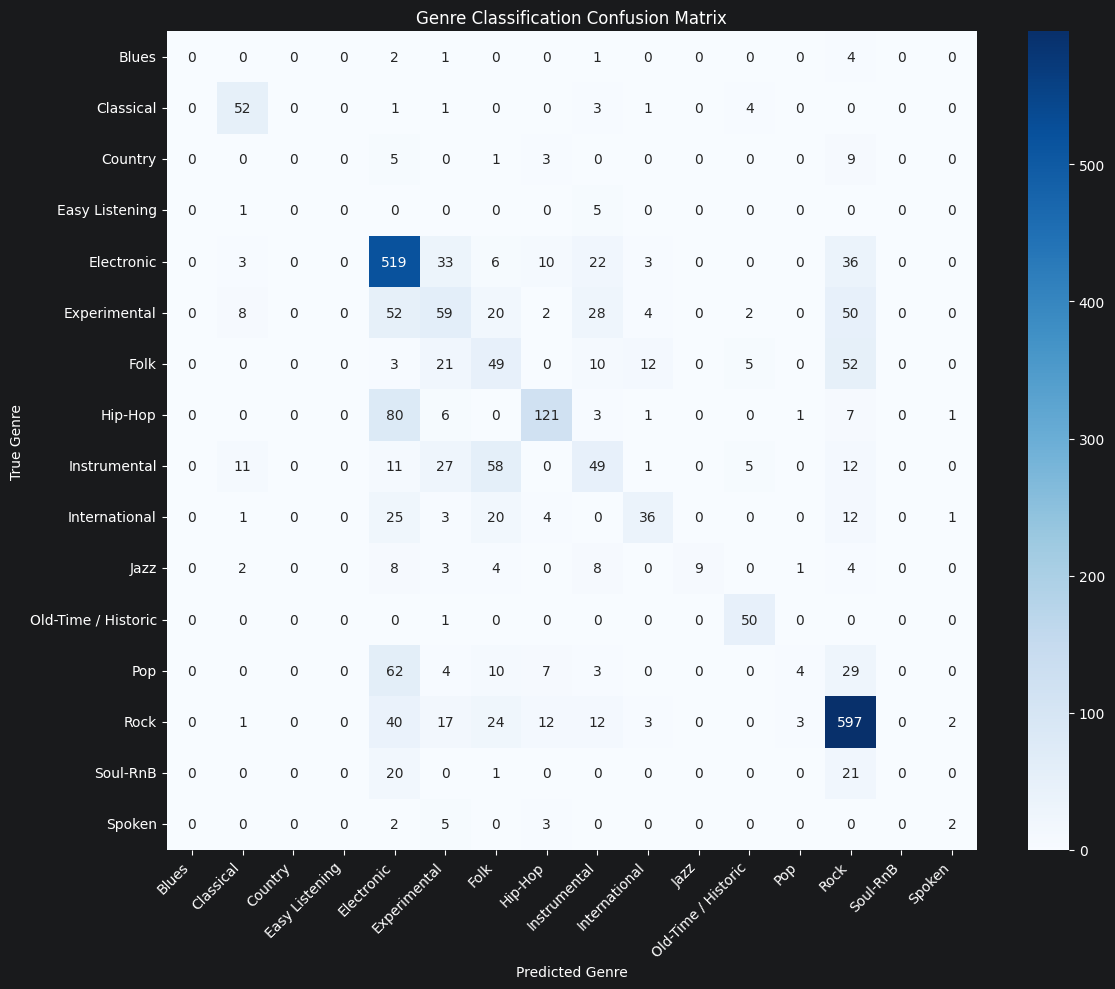

In [13]:
# Router evaluation
print("Computing accuracy...")
y_pred = router.predict(X_test)
accuracy = np.mean(y_pred == y_test_enc)

print(f"Initial Accuracy on medium Set: {accuracy:.2%}")
y_pred = router.predict(X_test)

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=router_le.classes_,
            yticklabels=router_le.classes_)

plt.title('Genre Classification Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../images/main/Router_cfm.png')

print("metrics:")
print(classification_report(y_test_enc, y_pred, zero_division=0))

In [9]:
# Training specialists

top_10_roots = [
    'Rock', 'Electronic', 'Experimental', 'Hip-Hop', 'Folk',
    'Instrumental', 'Pop', 'Jazz', 'Classical', 'International'
]


# Load genres metadata
genres = pd.read_csv('../data/fma_metadata/genres.csv')
genre_id_to_name = dict(zip(genres['genre_id'], genres['title']))

specialist_models = {}
specialist_label_encoders = {}
specialist_scalers = {}

for root in top_10_roots:
    print(f"--- Training Specialist for: {root} ---")

    is_medium = tracks['set', 'subset'] <= 'medium'
    current_root_mask = tracks.loc[is_medium, ('track', 'genres')].apply(
        lambda x: genre_to_root_map[x[0]] if len(x) > 0 else None
    ) == root

    y_subs = tracks.loc[is_medium].loc[current_root_mask, ('track', 'genres')].apply(lambda x: x[0])

    y_subs = y_subs.map(genre_id_to_name)

    X_subs = features.loc[y_subs.index].values

    split = tracks.loc[y_subs.index, ('set', 'split')]
    train_idx = split == 'training'
    test_idx = split == 'test'

    if train_idx.sum() < 10 or test_idx.sum() < 2:
        print(f"Skipping {root}: Not enough data.")
        continue

    X_train_sub, X_test_sub = X_subs[train_idx], X_subs[test_idx]
    y_train_sub, y_test_sub = y_subs[train_idx], y_subs[test_idx]

    scaler = StandardScaler()
    X_train_sub = scaler.fit_transform(X_train_sub)
    X_test_sub = scaler.transform(X_test_sub)
    joblib.dump(scaler, f'../models/{root}/{root}_scaler')

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train_sub)
    joblib.dump(le, f'../models/{root}/{root}_encoder')

    valid_test_mask = y_test_sub.isin(le.classes_)
    X_test_sub = X_test_sub[valid_test_mask]
    y_test_sub = y_test_sub[valid_test_mask]
    y_test_enc = le.transform(y_test_sub)

    rf = WeightedRandomForest(n_estimators=500, features_per_other_cat=25)
    _, counts = np.unique(y_train_enc, return_counts=True)
    min_samples = counts.min()
    k = min(5, min_samples - 1) if min_samples > 1 else 1

    '''
    if min_samples > 1:
        smote = SMOTE(k_neighbors=k, random_state=42)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_sub, y_train_enc)
        rf.fit(X_train_bal, y_train_bal)
    else:
        # Fallback to balanced class weights if a sub-genre has only 1 sample
        rf.fit(X_train_sub, y_train_enc)

    rf.save(f'../models/{root}/{root}_model')
    '''

    rf.load(f'../models/{root}/{root}_model')

    specialist_models[root] = rf
    specialist_label_encoders[root] = le
    specialist_scalers[root] = scaler

    # Confusion matrix
    y_pred = rf.predict(X_test_sub)
    print(len(le.classes_))
    print(f"Sample count: {X_subs.shape[0]}")
    print(f"Report for {root}: {classification_report(y_test_enc, y_pred, zero_division=0)}")
    '''
    cm = confusion_matrix(y_test_enc, y_pred)

    class_names = le.classes_

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f'{root} Sub-Genre Confusion Matrix')
    plt.xlabel('Predicted Sub-Genre ID')
    plt.ylabel('True Sub-Genre ID')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.savefig(f'../images/main/{root}_cfm.png')
    plt.close()
    '''

--- Training Specialist for: Rock ---
Model loaded from ../models/Rock/Rock_model
28
Sample count: 7103
Report for Rock:               precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         9
           3       0.44      0.11      0.17        37
           4       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        23
           7       0.12      0.20      0.15        45
           8       0.06      0.33      0.11         3
          10       0.18      0.07      0.10        42
          11       0.00      0.00      0.00         6
          12       0.38      0.38      0.38         8
          14       0.00      0.00      0.00         9
          15       0.00      0.00      0.00        20
          16       0.00      0.00      0.00         9
          17       0.04      0.08      0.05        12
          18       0.00      0.00      0.00        17
          19  

In [8]:
final_results = []
correct_top = 0
correct_full = 0

sub_genres = tracks.loc[is_medium, ('track', 'genres')].apply(lambda x: x[0] if len(x) > 0 else None)
y_test_subs = sub_genres.loc[test_mask]
y_test_subs = y_test_subs[test_valid]

for i in range(len(X_test)):
    raw_features = X_test[i:i+1]

    root_pred_enc = router.predict(raw_features)[0]
    root_pred_name = router_le.inverse_transform([root_pred_enc])[0]

    actual_root = y_test.iloc[i]
    actual_sub = y_test_subs.iloc[i]

    predicted_sub_id = None

    if root_pred_name in specialist_models:
        spec_scaler = specialist_scalers[root_pred_name]
        spec_model = specialist_models[root_pred_name]
        spec_le = specialist_label_encoders[root_pred_name]

        X_scaled_spec = spec_scaler.transform(raw_features)

        sub_pred_enc = spec_model.predict(X_scaled_spec)[0]
        predicted_sub_id = spec_le.inverse_transform([sub_pred_enc])[0]
    else:
        predicted_sub_id = "N/A"

    root_match = str(root_pred_name).strip() == str(actual_root).strip()

    sub_match = False
    if root_match and predicted_sub_id != "N/A":
        sub_match = str(predicted_sub_id).strip() == str(actual_sub).strip()

    if root_match: correct_top += 1
    if sub_match: correct_full += 1

    final_results.append({
        'Actual Root': actual_root,
        'Pred Root Name': root_pred_name,
        'Actual Sub ID': actual_sub,
        'Pred Sub ID': predicted_sub_id,
        'Correct': sub_match
    })

total = len(X_test)
print(f"\nResults for {total} tracks:")
print(f"Router Accuracy (Top-Level): {correct_top/total:.2%}")
print(f"Total System Accuracy (Root + Sub-genre): {correct_full/total:.2%}")


Results for 2573 tracks:
Router Accuracy (Top-Level): 59.93%
Total System Accuracy (Root + Sub-genre): 0.00%
